# Introduccion al entorno y base de datos

## Introduccion al entorno y a la base de datos


Este primer notebook sera dedicado a hacer una breve introduccion al entorno y un analisis simple sobre los datos.  

### Entorno
En estos notebooks utilizaremos python3 para analizar los datos, trabajando con los siguientes modulos para Data Sciece:

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import empiricaldist
import sqlite3
import scipy.stats
conn = sqlite3.connect("../data/Datos_Limpios.db")

### Base de datos

La base de datos que utilizaremos para este proyecto, "Datos_Limpios", esta hecha por mi, utilizando los siguientes datasets: 

Datos partidos mundial 2026:
https://www.kaggle.com/datasets/swaptr/fifa-wc-2026-matches

Elo Ratings Historicos:
https://www.kaggle.com/datasets/saifalnimri/international-football-elo-ratings

Datos partidos mundiales:
https://www.kaggle.com/datasets/joshfjelstul/world-cup-database?

Datos partidos internacionales:
https://www.kaggle.com/datasets/martj42/international-football-results-from-1872-to-2017?

Datos_Limpios contiene dos tipos de tablas:  
 Tablas maestras de identificacion, las cuales permiten ubicar la mayoria de los ID de datos que aparecen en las tablas a su respectivo valor.  
-teams_master y team_aliases: teams_master contiene el nombre e id por el cual se identifica a cada region la cual esta presente en un partido. En cambio
team aliases contiene los distintos alias para los que se puede referir a un mismo pais ya presente en teams_master, junto con su respectivo id de esta misma tabla.  
-tournament_master: El cual nos permite identificar para unas tablas de partido que tipo de torneo se estaba jugando:

In [9]:
query = "SELECT * FROM teams_master"
tm = pd.read_sql_query(query, conn)
tm

,team_id,canonical_name,fifa_code,confederation
0,1,Afghanistan,AFG,AFC
1,2,Albania,ALB,UEFA
2,3,Algeria,ALG,CAF
3,4,Andorra,AND,UEFA
4,5,Angola,ANG,CAF
...,...,...,...,...
231,232,Palau,PLW,AFC
232,233,São Tomé and Príncipe,NaN,CAF
233,234,Saint Vincent and the Grenadines,NaN,CONCACAF
234,235,Saint Kitts and Nevis,NaN,CONCACAF


In [10]:
query = "SELECT * FROM team_aliases"
ta = pd.read_sql_query(query, conn)
ta

,alias,team_id
0,Czechoslovakia,45
1,West Germany,65
2,Soviet Union,140
3,Yugoslavia,144
4,East Germany,65
...,...,...
115,Sao Tome and Principe,233
116,Germany DR,65
117,Bosnia–Herz,23
118,Cabo Verde,33


In [11]:
query = "SELECT * FROM tournament_master"
ttm = pd.read_sql_query(query, conn)
ttm

,tournament_id,tournament_name,competition_type,region
0,1,FIFA World Cup,World Cup,FIFA
1,2,FIFA World Cup qualification,Qualification,FIFA
2,3,Confederations Cup,International Tournament,FIFA
3,4,FIFA Series,International Tournament,FIFA
4,5,FIFA 75th Anniversary Cup,International Tournament,FIFA
...,...,...,...,...
196,197,South Asian Super Cup,other,NaN
197,198,Al Ain International Cup,other,NaN
198,199,Mukuru 4 Nations,other,NaN
199,200,Diamond Jubilee International Football Tournament,other,NaN


Luego estan las tablas que mas nos interesan, por que son las que nos van a brindar los datos con los que vamos a trabajar:

 -results_shootouts: Contiene todos los partidos internacionales a nivel seleccion que nos interesan para el analisis, incluyendo cualquier torneo o amistoso entre cualquier equipo.  
 -world_cup_matches: Por su nombre, tiene todos los partidos de mundiales, usamos esta tabla para sacar datos de mundiales. Pese a que results_shootouts tambien tiene todos los partidos de mundiales, world_cup_matches es mas completo en datos que nos brinda.  
 -eloratings_clean: La cual contiene el historial de cambios de puntaje elo FIFA para todas las selecciones. Ahora no lo usaremos mucho, pero lo tomaremos para prediccion.

In [12]:
query = "SELECT * FROM world_cup_matches"
wcm = pd.read_sql_query(query, conn)
wcm

,match_id,date,home_team,home_team_id,away_team,away_team_id,round,home_score,away_score,neutral,...,away_penalty_score,home_xg,away_xg,home_possession,away_possession,home_sot,away_sot,home_shots,away_shots,result
0,1408,1930-07-13,United States,175,Belgium,17,Group stage,3,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,home team win
1,1409,1930-07-13,France,61,Mexico,110,Group stage,4,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,home team win
2,1410,1930-07-14,Yugoslavia,144,Brazil,25,Group stage,2,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,home team win
3,1411,1930-07-14,Romania,139,Peru,134,Group stage,3,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,home team win
4,1412,1930-07-15,Argentina,7,France,61,Group stage,1,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,home team win
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1063,48061,2026-07-11,Norway,127,England,53,Quarter-finals,1,2,1,...,NaN,0.77,0.96,48.0,52.0,4.0,8.0,13.0,14.0,away team win
1064,48062,2026-07-14,France,61,Spain,155,Semi-finals,0,2,1,...,NaN,0.30,1.63,49.0,51.0,3.0,2.0,10.0,10.0,away team win
1065,48063,2026-07-15,England,53,Argentina,7,Semi-finals,1,2,1,...,NaN,0.54,1.80,36.0,64.0,2.0,5.0,5.0,15.0,away team win
1066,48064,2026-07-18,France,61,England,53,Third-place match,4,6,1,...,NaN,2.88,2.88,46.0,54.0,9.0,11.0,19.0,19.0,away team win


In [13]:
query = "SELECT * FROM results_shootouts"
rs = pd.read_sql_query(query, conn)
rs

,match_id,date,home_team,away_team,home_team_id,away_team_id,home_score,away_score,neutral,country,country_id,has_shootouts,winner_on_shootouts,winner,tournament,tournament_id,result,local_team_id,local
0,3204,1950-01-24,Zambia,DR Congo,183,194,1,0,0,Northern Rhodesia,183.0,0,NaN,Zambia,Friendly,97,home team win,183.0,home team
1,3205,1950-02-17,Egypt,Greece,51,67,2,0,0,Egypt,51.0,0,NaN,Egypt,Friendly,97,home team win,51.0,home team
2,3206,1950-02-26,Bolivia,Chile,22,36,2,0,0,Bolivia,22.0,0,NaN,Bolivia,Friendly,97,home team win,22.0,home team
3,3207,1950-02-26,Croatia,Serbia,42,144,4,1,0,Yugoslavia,144.0,0,NaN,Croatia,Friendly,97,home team win,144.0,away team
4,3208,1950-03-05,Italy,Belgium,84,17,3,1,0,Italy,84.0,0,NaN,Italy,Friendly,97,home team win,84.0,home team
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44857,48061,2026-07-11,Norway,England,127,53,1,2,1,United States,175.0,0,NaN,England,FIFA World Cup,1,away team win,NaN,NaN
44858,48062,2026-07-14,France,Spain,61,155,0,2,1,United States,175.0,0,NaN,Spain,FIFA World Cup,1,away team win,NaN,NaN
44859,48063,2026-07-15,England,Argentina,53,7,1,2,1,United States,175.0,0,NaN,Argentina,FIFA World Cup,1,away team win,NaN,NaN
44860,48064,2026-07-18,France,England,61,53,4,6,1,United States,175.0,0,NaN,England,FIFA World Cup,1,away team win,NaN,NaN


In [14]:
query = "SELECT * FROM eloratings_clean"
elos = pd.read_sql_query(query, conn)
elos

,date,team,rating,change,team_id
0,1872-11-30,England,2003,3,53.0
1,1872-11-30,Scotland,1997,-3,185.0
2,1873-03-08,England,2014,11,53.0
3,1873-03-08,Scotland,1986,-11,185.0
4,1874-03-07,England,2006,-8,53.0
...,...,...,...,...,...
6673,2025-12-13,Northern Mariana Islands,432,0,230.0
6674,2025-12-13,Cocos Islands,422,0,231.0
6675,2025-12-13,Palau,402,0,232.0
6676,2025-12-13,Eastern Samoa,389,0,214.0


Con esto podemos ya empezar a hacer unos breves analisis para empezar

## Evolucion de goles por edicion



Para empezar, me gustaria ver como ha cambiado la cantidad de goles que se ven por partidos a medida que ha avanzado el deporte. 
Para eso, utilicemos world_cup_matches (wcm):  
Podemos obtener cada edicion mundialista agrupando wcm por año con la columna date.
La columna date de wcm esta guardada como un string del tipo "año-mes-dia", pasemosla a formato Date de pandas para trabajar con esta correctamente.
Luego filtremos el ultimo año de mundial:

In [62]:
wcm["date"] = pd.to_datetime(wcm["date"])

wcm_2026 = wcm[wcm["date"].dt.year == 2026]

wcm_2026

,match_id,date,home_team,home_team_id,away_team,away_team_id,round,home_score,away_score,neutral,...,away_penalty_score,home_xg,away_xg,home_possession,away_possession,home_sot,away_sot,home_shots,away_shots,result
964,47962,2026-06-11,South Korea,153,Czech Republic,45,Group stage,2,1,1,...,NaN,1.45,1.12,62.0,38.0,6.0,4.0,15.0,7.0,home team win
965,47963,2026-06-11,Mexico,110,South Africa,152,Group stage,2,0,0,...,NaN,1.84,0.52,61.0,40.0,4.0,2.0,16.0,3.0,home team win
966,47964,2026-06-12,Canada,32,Bosnia and Herzegovina,23,Group stage,1,1,0,...,NaN,1.35,0.98,61.0,39.0,4.0,3.0,13.0,8.0,draw
967,47965,2026-06-12,United States,175,Paraguay,133,Group stage,4,1,0,...,NaN,2.76,0.88,65.0,35.0,6.0,1.0,16.0,9.0,home team win
968,47966,2026-06-13,Australia,9,Turkey,170,Group stage,2,0,1,...,NaN,1.48,0.72,28.0,72.0,4.0,8.0,9.0,30.0,home team win
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1063,48061,2026-07-11,Norway,127,England,53,Quarter-finals,1,2,1,...,NaN,0.77,0.96,48.0,52.0,4.0,8.0,13.0,14.0,away team win
1064,48062,2026-07-14,France,61,Spain,155,Semi-finals,0,2,1,...,NaN,0.30,1.63,49.0,51.0,3.0,2.0,10.0,10.0,away team win
1065,48063,2026-07-15,England,53,Argentina,7,Semi-finals,1,2,1,...,NaN,0.54,1.80,36.0,64.0,2.0,5.0,5.0,15.0,away team win
1066,48064,2026-07-18,France,61,England,53,Third-place match,4,6,1,...,NaN,2.88,2.88,46.0,54.0,9.0,11.0,19.0,19.0,away team win


Podemos corroborar que es correcto por que el ultimo mundial tuvo 104 partidos, cada uno representado por una fila de este subquery. Ahora fijemonos en los goles de esta edicion, que en las tablas de resultados de partido estan en las columnas home_score y away_score.  
Para obtener correctamente la suma de todos los goles por partido, lo que tendriamos que hacer es obtener una serie que contenga por cada partido, la suma de home_score + away_score para ese partido.

In [63]:
home_score_2026 = wcm_2026["home_score"]
away_score_2026 = wcm_2026["away_score"]
home_score_2026, away_score_2026
scores_2026 = home_score_2026 + away_score_2026

Para verificar que estos resultados son correctos, los primeros cinco elementos de scores_2026 deberian ser cada uno la suma de los primeros cinco elementos de home_score_2026 y away_score_2026.

In [64]:
home_score_2026.head(), away_score_2026.head(), scores_2026.head()

(964    2
 965    2
 966    1
 967    4
 968    2
 Name: home_score, dtype: int64,
 964    1
 965    0
 966    1
 967    1
 968    0
 Name: away_score, dtype: int64,
 964    3
 965    2
 966    2
 967    5
 968    2
 dtype: int64)

La suma total de los elementos de scores_2026 seria la cantidad de goles en toda la edicion mundialista.  
Como nos interesa comparar este mundial con otros para visualizar como ha cambiado la frecuencia de goles, no podemos simplemente evaluar la cantidad total de goles porque las ediciones varian en cantidad de partidos. Justamente esta ultima edicion es la que contiene la mayor cantidad de partidos, 104. 

Por lo cual seria mas confiable verificar la cantidad de goles por partido por cada edicion (goal_avg).

In [65]:
goal_avg_2026 = np.round(np.divide(scores_2026.sum(), scores_2026.count()), decimals=2)
scores_2026.count(), scores_2026.sum(), goal_avg_2026

(np.int64(104), np.int64(308), np.float64(2.96))

Siguiendo estos pasos, podemos crear un DataFrame de Pandas que contenga estos datos por cada edicion mundialista:

In [81]:
goles_por_edicion = pd.DataFrame(
    columns=["Edicion (año)", "promedio de goles", "cant goles", "cant partidos"]
)
for año, edicion in wcm.groupby(wcm["date"].dt.year):
    count = len(edicion)
    scores = (edicion["home_score"] + edicion["away_score"]).sum()
    goal_avg = np.divide(scores, count)

    goles_por_edicion.loc[len(goles_por_edicion)] = [
        año,
        np.round(goal_avg, 2),
        scores,
        count
    ]
goles_por_edicion

,Edicion (año),promedio de goles,cant goles,cant partidos
0,1930.0,3.89,70.0,18.0
1,1934.0,4.12,70.0,17.0
2,1938.0,4.67,84.0,18.0
3,1950.0,4.00,88.0,22.0
4,1954.0,5.38,140.0,26.0
5,1958.0,3.60,126.0,35.0
6,1962.0,2.78,89.0,32.0
7,1966.0,2.78,89.0,32.0
8,1970.0,2.97,95.0,32.0
9,1974.0,2.55,97.0,38.0


Luego, con estos datos podriamos crear una simple serie temporal con datos discretos, utilizando el promedio de goles:

(0.0, 5.5385)

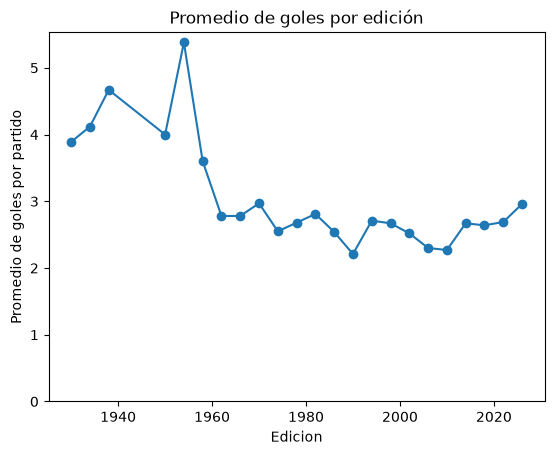

In [93]:
plt.plot(
    goles_por_edicion["Edicion (año)"],
    goles_por_edicion["promedio de goles"],
    marker="o"
)

plt.xlabel("Edicion")
plt.ylabel("Promedio de goles por partido")
plt.title("Promedio de goles por edición")
plt.ylim(bottom=0)

Ahora es mas facil visualizar la tendencia, desde 1930 hasta aprox 1958, el promedio de goles por partido ha variado mucho entre aproximadamente 3.6 y 5.4.  
En 1962 cayo a 2.7, desde ahi empezo a variar en menor magnitud, alcanzando dos minimos en 1990(2.21) y 2010(2.27), pero permaneciendo la mayoria de las veces entre 2.2 y 2.9.

#Aniadir a los otros notebooks intervalos de confianza (CI o IC)
# ANIADIR INTERVALOS DE CONFIANZA A LOS MODELOS PREDICTIVOS NO OLVIDAR